## Michigan DNR Trail Data Audit and Preparation

This notebook documents the completed audit and preparation workflow for the downloaded Michigan DNR Upper Peninsula hiking-trail data. It inspects the 2,437 source segments, resolves encoded missing values and known naming aliases, dissolves the segments into 138 county-specific trail records, validates the grouped geospatial data, and assigns trail-length categories.

In [22]:
from pathlib import Path
import sys

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt 

sys.path.append("..")

from src.trails import (
    group_trails,
    prep_columns,
    replace_missing_placeholders,
    PLACEHOLDER_VALUES,
    combine_unique,
    aggregate_column,
    add_length_category
)

### 1. Load and inspect the raw trail segments

The raw GeoJSON download was loaded as a GeoDataFrame and checked for its basic shape, coordinate reference system, schema, and sample values. The recorded run contains **2,437 segment records**, **15 columns**, and line geometry in **WGS 84 (`EPSG:4326`)**. Every source record has a unique `OBJECTID`.

In [ ]:
DATA_PATH = Path("../data/raw/dnr_up_hiking_trails.geojson")

trails = gpd.read_file(DATA_PATH)

print(f"Rows: {len(trails):,}")
print(f"Columns: {len(trails.columns)}")
print(f"CRS: {trails.crs}")
trails.head()

Rows: 2,437
Columns: 15
CRS: EPSG:4326


,OBJECTID,DNRTrail,TrailNamePrimary,HikingName,FacilityName,County,Peninsula,Hiking,TrailUseCategory,OpenClosedStatusNonmotor,SurfaceType,TrailWidthFeet,ADAAccessible,SegmentLengthMiles,geometry
0,1919,DNR Trail,Straits - Main Trail,Straits Main Trail,Straits State Park,Mackinac,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.006157,"LINESTRING (-84.72138 45.84982, -84.72135 45.8..."
1,2486,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.200800,"LINESTRING (-87.47649 46.63472, -87.47644 46.6..."
2,2495,DNR Trail,UP 2,North Country Trail,-1,Mackinac,Upper Peninsula,Hiking,Multi Use Motorized Nonmotorized,Open,Dirt Natural,12 Feet And Over,Not Accessible,3.891672,"LINESTRING (-84.73683 45.87386, -84.73687 45.8..."
3,2540,DNR Trail,Gemini Lake Pathway,Gemini Lake Pathway,State Forest,Schoolcraft,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.514227,"LINESTRING (-86.30655 46.48498, -86.30623 46.4..."
4,2541,DNR Trail,Gemini Lake Pathway,Gemini Lake Pathway,State Forest,Schoolcraft,Upper Peninsula,Hiking,Nonmotorized,Open,Dirt Natural,0 To 2 Feet,Not Accessible,0.264824,"LINESTRING (-86.30464 46.48159, -86.30522 46.4..."


In [24]:
trails.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2437 entries, 0 to 2436
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   OBJECTID                  2437 non-null   int32   
 1   DNRTrail                  2437 non-null   str     
 2   TrailNamePrimary          2437 non-null   str     
 3   HikingName                2437 non-null   str     
 4   FacilityName              2437 non-null   str     
 5   County                    2437 non-null   str     
 6   Peninsula                 2437 non-null   str     
 7   Hiking                    2437 non-null   str     
 8   TrailUseCategory          2437 non-null   str     
 9   OpenClosedStatusNonmotor  2437 non-null   str     
 10  SurfaceType               2437 non-null   str     
 11  TrailWidthFeet            2437 non-null   str     
 12  ADAAccessible             2437 non-null   str     
 13  SegmentLengthMiles        2437 non-null 

### 2. Review trail status, nulls, and field cardinality

Status values and field-level uniqueness were reviewed before cleaning. Seven segments are marked `Temporarily Closed`, all under Little Presque Isle Multi Use Pathway. The source reports no conventional null values, but several fields use text or numeric-looking codes instead of true missing values.

The cardinality review found **135 `HikingName` values**, **119 primary trail names**, and **15 counties**. `DNRTrail`, `Peninsula`, and `Hiking` each contain only one value in this Upper Peninsula hiking subset, so they do not add information for later grouping.

In [25]:
mask = (trails["OpenClosedStatusNonmotor"] == "Temporarily Closed")

trails.loc[mask]

,OBJECTID,DNRTrail,TrailNamePrimary,HikingName,FacilityName,County,Peninsula,Hiking,TrailUseCategory,OpenClosedStatusNonmotor,SurfaceType,TrailWidthFeet,ADAAccessible,SegmentLengthMiles,geometry
1,2486,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.200800,"LINESTRING (-87.47649 46.63472, -87.47644 46.6..."
112,3514,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.445860,"LINESTRING (-87.49289 46.63979, -87.49189 46.6..."
113,3515,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.259620,"LINESTRING (-87.48695 46.64034, -87.48692 46.6..."
114,3516,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.432088,"LINESTRING (-87.48435 46.63729, -87.48407 46.6..."
117,3521,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.224164,"LINESTRING (-87.46916 46.63441, -87.46845 46.6..."
119,3524,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,1.786506,"LINESTRING (-87.47457 46.63158, -87.47459 46.6..."
2025,12306,DNR Trail,Little Presque Isle Multi Use Pathway,Little Presque Isle Multi Use Pathway,State Forest,Marquette,Upper Peninsula,Hiking,Nonmotorized,Temporarily Closed,Dirt Natural,-1,Not Accessible,0.023261,"LINESTRING (-87.47832 46.6062, -87.47822 46.60..."


In [26]:
trails.isna().sum().sort_values(ascending=False)

OBJECTID                    0
DNRTrail                    0
TrailNamePrimary            0
HikingName                  0
FacilityName                0
County                      0
Peninsula                   0
Hiking                      0
TrailUseCategory            0
OpenClosedStatusNonmotor    0
SurfaceType                 0
TrailWidthFeet              0
ADAAccessible               0
SegmentLengthMiles          0
geometry                    0
dtype: int64

In [27]:
unique_counts = (
    trails.nunique(dropna=False)
    .rename("unique_count")
    .reset_index()
    .rename(columns = {"index":"column"})
)

unique_counts

,column,unique_count
0,OBJECTID,2437
1,DNRTrail,1
2,TrailNamePrimary,119
3,HikingName,135
4,FacilityName,25
5,County,15
6,Peninsula,1
7,Hiking,1
8,TrailUseCategory,2
9,OpenClosedStatusNonmotor,4


### 3. Audit encoded missing values

A placeholder audit was completed across all text fields because the initial null count understated missing data. It found **658 encoded missing values in `FacilityName` (27.00%)**, **36 in `TrailWidthFeet` (1.48%)**, **33 in `ADAAccessible` (1.35%)**, and **13 in `SurfaceType` (0.53%)**. The observed placeholders include `-1`, `-99`, and `Unspecified`. The shared `PLACEHOLDER_VALUES` definition and `replace_missing_placeholders()` function convert these values to `pd.NA` consistently.

In [28]:
text_columns = trails.select_dtypes(
    include=["object","string"]
).columns

placeholder_records = []

for column in text_columns:
    normalized = trails[column].astype("string").str.strip()
    matches = normalized.isin(PLACEHOLDER_VALUES)

    placeholder_records.append(
        {
            "column": column,
            "placeholder_count": int(matches.sum()),
            "placeholder_percent": round(matches.mean() * 100, 2),
            "values_found": sorted(
                normalized.loc[matches].dropna().unique().tolist()
            ),
        }
    )

placeholder_audit = (
    pd.DataFrame(placeholder_records)
    .sort_values("placeholder_count", ascending=False)
    .reset_index(drop=True)
)

placeholder_audit

,column,placeholder_count,placeholder_percent,values_found
0,FacilityName,658,27.00,"[-1, Unspecified]"
1,TrailWidthFeet,36,1.48,[-1]
2,ADAAccessible,33,1.35,[-99]
3,SurfaceType,13,0.53,[-1]
4,HikingName,0,0.00,[]
5,TrailNamePrimary,0,0.00,[]
6,DNRTrail,0,0.00,[]
7,County,0,0.00,[]
8,TrailUseCategory,0,0.00,[]
9,Hiking,0,0.00,[]


### 4. Evaluate trail names and choose a grouping key

After converting placeholders to missing values, `HikingName` was compared across counties, facilities, and primary names. Major routes span multiple counties. For example, North Country Trail appears in nine counties and Iron Belle Trail appears in seven, so `HikingName` alone is too broad for the local trail records used by the application.

The preparation logic first standardizes known county-specific aliases, then combines `County` and the canonical `HikingName` as `TrailGroupName`. Alias normalization reduces the raw county-and-name combinations from **159 to 138 final trail identifiers**.

In [29]:
cleaned_data = replace_missing_placeholders(trails)


hiking_name_audit = (
    cleaned_data.groupby("HikingName", dropna=False)
    .agg(
        segment_count=("OBJECTID", "size"),
        county_count=("County", "nunique"),
        facility_count=("FacilityName","nunique"),
        primary_name_count=("TrailNamePrimary","nunique"),
        counties=(
            "County",
            lambda values: sorted(
                values.dropna().astype(str).unique()
            ),
        ),
        facilities=(
            "FacilityName",
            lambda values: sorted(
                values.dropna().astype(str).unique()   
            ),
        ),
    )
    .sort_values(
        ["county_count", "facility_count", "segment_count"],
        ascending=False,
    )
)

print(f"Unique hiking names: {len(hiking_name_audit):,}")
hiking_name_audit.head(30)

Unique hiking names: 135


,segment_count,county_count,facility_count,primary_name_count,counties,facilities
HikingName,,,,,,
North Country Trail,597,9,6,10,['Alger' 'Baraga' 'Chippewa' 'Gogebic' 'Hought...,['Craig Lake State Park' 'Porcupine Mountains ...
Iron Belle Trail,15,7,1,4,['Delta' 'Luce' 'Mackinac' 'Marquette' 'Menomi...,['Porcupine Mountains Wilderness State Park']
Porcupine Mountain Wilderness Lake Superior Trail,128,2,1,3,['Gogebic' 'Ontonagon'],['Porcupine Mountains Wilderness State Park']
Porcupine Mts Big Carp River Trail,78,2,1,2,['Gogebic' 'Ontonagon'],['Porcupine Mountains Wilderness State Park']
Porcupine Mountain Wilderness - Lake Superior Trail,72,2,1,1,['Gogebic' 'Ontonagon'],['Porcupine Mountains Wilderness State Park']
Fox River Pathway,24,2,1,2,['Alger' 'Schoolcraft'],['State Forest']
Tahquamenon Falls State Park Lower Falls Foot Trails,22,2,1,2,['Chippewa' 'Luce'],['Tahquamenon Falls State Park']
Tahquamenon Falls River Trail,14,2,1,1,['Chippewa' 'Luce'],['Tahquamenon Falls State Park']
Porcupine Mountain Wilderness Cross Trail Correction Line Trail,12,2,1,2,['Gogebic' 'Ontonagon'],['Porcupine Mountains Wilderness State Park']


### 5. Apply and validate reusable preparation steps

The notebook applies `replace_missing_placeholders()` and `prep_columns()` from `src.trails`. These functions preserve all **2,437 rows**, remove the invariant `DNRTrail`, `Peninsula`, and `Hiking` fields, standardize the known trail-name aliases, and create a non-missing `TrailGroupName` for every segment. Assertions confirm that `OBJECTID` remains unique after preparation.

In [30]:
prep_data = prep_columns(cleaned_data)

assert len(prep_data) == len(trails)
assert prep_data["OBJECTID"].is_unique
assert prep_data["TrailGroupName"].notna().all()

### 6. Explore attribute aggregation rules

Before dissolving geometry, the notebook reviews within-group width variation and builds a preliminary attribute summary. The summary checks segment counts, summed DNR-reported lengths, facility counts, surface types, status counts, and trail widths across the **138 normalized trail groups**.

`combine_unique()` preserves multiple reported values as a sorted, comma-separated string. For trail width, `aggregate_column()` keeps one value when all reported segments agree, returns `Varies` when they disagree, and returns `Unknown` when every value is missing.

In [31]:
width_counts = (
    prep_data
    .groupby("TrailGroupName")["TrailWidthFeet"]
    .nunique(dropna=True)
)

width_counts.head(10)

TrailGroupName
Alger | Fox River Pathway                          1
Alger | Laughing Whitefish Falls Trails            1
Alger | North Country Trail                        2
Alger | Tyoga Historical Pathway                   1
Alger | Wagner Falls Scenic Site - Foot Trail      1
Baraga | Baraga Nature Trail                       1
Baraga | Craig Lake Clair Lake Portage             1
Baraga | Craig Lake Clair Lake Trail               1
Baraga | Craig Lake Craig Lake Trail               1
Baraga | Craig Lake Crooked Lake Campsite Trail    1
Name: TrailWidthFeet, dtype: int64

In [32]:
trail_group_summary = (
    prep_data.groupby("TrailGroupName")
    .agg(
        segment_count=("OBJECTID", "size"),
        reported_length_miles=("SegmentLengthMiles", "sum"),
        facility_count=("FacilityName", "nunique"),
        surface_type=("SurfaceType", combine_unique),
        status_count=("OpenClosedStatusNonmotor", "nunique"),
        trail_width=("TrailWidthFeet", aggregate_column),
    )
    .sort_values("reported_length_miles", ascending=False)
)

trail_group_summary.head(30)

,segment_count,reported_length_miles,facility_count,surface_type,status_count,trail_width
TrailGroupName,,,,,,
Alger | North Country Trail,129,96.990313,1,"Concrete, Dirt Natural",1,Varies
Marquette | North Country Trail,60,74.256774,1,"Asphalt, Concrete, Dirt Natural, Gravel",1,Varies
Ontonagon | North Country Trail,100,73.306963,1,"Asphalt, Dirt Natural, Gravel",1,Varies
Chippewa | North Country Trail,148,66.307730,1,"Asphalt, Boardwalk, Concrete, Dirt Natural, Gr...",1,Varies
Mackinac | Iron Belle Trail,1,63.804200,0,Asphalt,1,0 To 2 Feet
Delta | Iron Belle Trail,6,52.355545,0,Asphalt,1,0 To 2 Feet
Marquette | Iron Ore Heritage Trail,49,50.502948,0,"Asphalt, Concrete, Crushed Limestone, Dirt Nat...",1,Varies
Baraga | North Country Trail,21,47.588697,1,"Dirt Natural, Gravel",1,Varies
Gogebic | North Country Trail,24,43.997004,1,"Asphalt, Concrete, Dirt Natural",1,Varies


### 7. Build and validate the grouped trail dataset

`group_trails()` dissolves the prepared segment geometries by `TrailGroupName`, producing one row for each of the **138 county-specific trails**. It sums `SegmentLengthMiles` into `ReportedLengthMiles`, counts source segments, combines unique facilities, surfaces, accessibility values, and statuses, and applies the trail-width summary rule. The resulting records retain either line or multiline geometry in the source CRS.

The validation assertions confirm that every group key is unique, every geometry is present and valid, the CRS remains `EPSG:4326`, and the grouped `SegmentCount` values account for all **2,437 original segments**.

In [33]:
grouped_trails = group_trails(prep_data)

grouped_trails.head(10)

,TrailGroupName,HikingName,County,ReportedLengthMiles,TrailWidth,SurfaceTypes,AccessibilityValues,TrailStatuses,FacilityName,SegmentCount,geometry
0,Alger | Fox River Pathway,Fox River Pathway,Alger,14.345076,0 To 2 Feet,Dirt Natural,Not Accessible,Open,State Forest,11,"MULTILINESTRING ((-86.22663 46.58784, -86.2266..."
1,Alger | Laughing Whitefish Falls Trails,Laughing Whitefish Falls Trails,Alger,2.575298,0 To 2 Feet,Dirt Natural,Not Accessible,Open,SPRK422,17,"MULTILINESTRING ((-87.06939 46.38376, -87.0693..."
2,Alger | North Country Trail,North Country Trail,Alger,96.990313,Varies,"Concrete, Dirt Natural",Not Accessible,Open,SPRK422,129,"MULTILINESTRING ((-85.93435 46.66256, -85.9341..."
3,Alger | Tyoga Historical Pathway,Tyoga Historical Pathway,Alger,1.252893,0 To 2 Feet,Dirt Natural,Not Accessible,Open,State Forest,2,"MULTILINESTRING ((-87.02677 46.5134, -87.02657..."
4,Alger | Wagner Falls Scenic Site - Foot Trail,Wagner Falls Scenic Site - Foot Trail,Alger,0.125517,0 To 2 Feet,Dirt Natural,Not Accessible,Open,Wagner Falls Scenic Site,1,"LINESTRING (-86.64908 46.38881, -86.64908 46.3..."
5,Baraga | Baraga Nature Trail,Baraga Nature Trail,Baraga,0.570022,0 To 2 Feet,Dirt Natural,Not Accessible,Open,Baraga State Park,2,"MULTILINESTRING ((-88.50096 46.76201, -88.5009..."
6,Baraga | Craig Lake Clair Lake Portage,Craig Lake Clair Lake Portage,Baraga,0.262088,0 To 2 Feet,Dirt Natural,Not Accessible,Open,Craig Lake State Park,2,"MULTILINESTRING ((-88.18357 46.62132, -88.1836..."
7,Baraga | Craig Lake Clair Lake Trail,Craig Lake Clair Lake Trail,Baraga,1.343826,0 To 2 Feet,Dirt Natural,Not Accessible,Open,Craig Lake State Park,1,"LINESTRING (-88.19284 46.6097, -88.19287 46.60..."
8,Baraga | Craig Lake Craig Lake Trail,Craig Lake Craig Lake Trail,Baraga,5.845377,0 To 2 Feet,Dirt Natural,Not Accessible,Open,Craig Lake State Park,45,"MULTILINESTRING ((-88.18695 46.60162, -88.1869..."
9,Baraga | Craig Lake Crooked Lake Campsite Trail,Craig Lake Crooked Lake Campsite Trail,Baraga,0.297381,0 To 2 Feet,Dirt Natural,Not Accessible,Open,Craig Lake State Park,1,"LINESTRING (-88.1716 46.60722, -88.17157 46.60..."


In [34]:
assert len(grouped_trails) == prep_data["TrailGroupName"].nunique()
assert grouped_trails["TrailGroupName"].is_unique
assert grouped_trails.geometry.notna().all()
assert grouped_trails.geometry.is_valid.all()
assert grouped_trails.crs == trails.crs
assert grouped_trails["SegmentCount"].sum() == len(trails)

### 8. Categorize trail lengths and review the distribution

`add_length_category()` classifies the summed DNR-reported length for each grouped trail using the project thresholds: **Short** is at most 2 miles, **Medium** is more than 2 and at most 7 miles, and **Long** is more than 7 miles. The final bar chart shows **69 short**, **40 medium**, and **29 long** trails, which together account for all 138 grouped records.

In [35]:
final_df = add_length_category(grouped_trails)

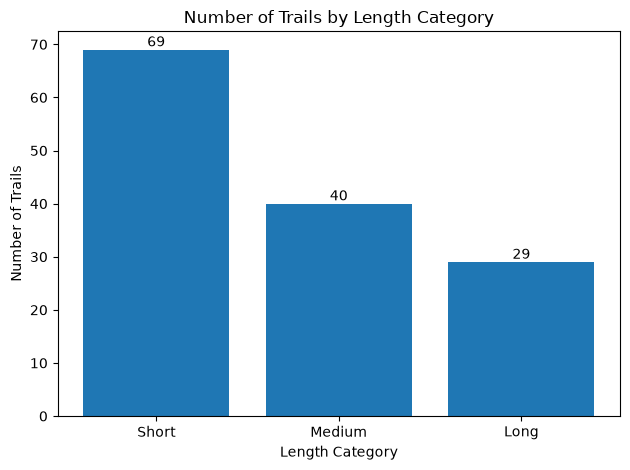

In [36]:
length_counts = (
    final_df["LengthCategory"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots()

bars = ax.bar(length_counts.index.astype(str), length_counts.values)
plt.bar_label(bars)
plt.title("Number of Trails by Length Category")
plt.xlabel("Length Category")
plt.ylabel("Number of Trails")
plt.tight_layout()
plt.show()

### Conclusion

The completed workflow transforms **2,437 DNR trail segments into 138 unique county-specific trail records**. It normalizes encoded missing values, consolidates known naming aliases, summarizes segment attributes, dissolves the geometries, and adds length categories.

All recorded validation assertions pass: the grouped keys are unique, geometries are non-missing and valid, the source CRS is preserved, and no source segments are lost during aggregation. The final length-category totals also reconcile to all 138 grouped trails.